# **Problema 2 – Regresión: Estimación de Edad a partir de Imágenes Faciales**
## Integrantes
* Antonia Muñoz Jiménez
* Luis Moreno Gutiérrez
* Juan Carlos Fernández Vanoy

## Dataset
* Nombre: Faces: Age Detection from Images
* Fuente: Kaggle – arashnic/faces-age-detection-dataset
* Descripción: Conjunto de imágenes faciales etiquetadas con la edad del sujeto. El objetivo es entrenar un modelo que estime la edad a partir de los píxeles de la imagen.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

---
# **Sección 1 - Análisis Preliminar del Problema**
**a.** Justifique por qué este es un problema de regresión e identifique claramente el target (variable objetivo).

**b.** Describa las características de entrada (imágenes): dimensiones, espacio de color, distribución de edades, etc.

**c.** Investigue y explique el protocolo de adquisición y/o generación de los datos.


In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_token = "---"
kaggle_user  = "---"

with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(f'{{"username":"{kaggle_user}","key":"{kaggle_token}"}}')

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configurado")

Kaggle configurado


In [ ]:
!kaggle datasets download -d arashnic/faces-age-detection-dataset
print("Descarga completa")

Dataset URL: https://www.kaggle.com/datasets/arashnic/faces-age-detection-dataset
License(s): CC0-1.0
100% 104M/104M [00:00<00:00, 170MB/s] 

Descarga completa


In [ ]:
import zipfile

# Descomprimimos el archivo descargado en una carpeta llamada faces_dataset
with zipfile.ZipFile('faces-age-detection-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('faces_dataset')

print("Descomprimido")

# Ver qué hay dentro
import os
for root, dirs, files in os.walk('faces_dataset'):
    level = root.replace('faces_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:
            print(f'{subindent}{file}')
        if len(files) > 5:
            print(f'{subindent}... y {len(files)-5} archivos más')

Descomprimido
faces_dataset/
  faces/
    train.csv
    Train/
  faces_02/
    part3/


---
# **Sección 2 - Análisis Exploratorio de Datos (EDA)**
* Distribución de edades en el dataset (histograma, estadísticos descriptivos).
* Análisis de balance y posibles sesgos en la distribución del target.
* Visualización de muestras representativas del dataset.
* Análisis de la calidad y variabilidad de las imágenes.

Cada visualización debe ir acompañada de una interpretación detallada orientada al problema de regresión.


In [ ]:
df_faces = pd.read_csv('faces_dataset/faces/train.csv')
print("Shape:", df_faces.shape)
print("\nColumnas:", df_faces.columns.tolist())
print("\nPrimeras filas:")
print(df_faces.head(10))
print("\nTipos de datos:")
print(df_faces.dtypes)

# Verificamos que no haya valores nulos (una imagen sin etiqueta)
print("\nValores nulos:")
print(df_faces.isnull().sum())

Shape: (19906, 2)

Columnas: ['ID', 'Class']

Primeras filas:
          ID   Class
0    377.jpg  MIDDLE
1  17814.jpg   YOUNG
2  21283.jpg  MIDDLE
3  16496.jpg   YOUNG
4   4487.jpg  MIDDLE
5   6283.jpg  MIDDLE
6  23495.jpg   YOUNG
7   7100.jpg   YOUNG
8   6028.jpg   YOUNG
9  22617.jpg     OLD

Tipos de datos:
ID       object
Class    object
dtype: object

Valores nulos:
ID       0
Class    0
dtype: int64


El dataset contiene 19,906 imágenes faciales, cada una asociada a una etiqueta categórica de edad (YOUNG, MIDDLE, OLD). No se encontraron valores nulos, lo que indica una buena calidad de los datos. Sin embargo, dado que el problema planteado es de regresión, es necesario transformar estas categorías en valores numéricos.

--- ANÁLISIS PRELIMINAR ---

Total de imagenes: 19,906
Clases unicas: ['MIDDLE' 'YOUNG' 'OLD']

Distribución de clases:
Class
MIDDLE    10804
YOUNG      6706
OLD        2396
Name: count, dtype: int64
Class
MIDDLE    54.3%
YOUNG     33.7%
OLD       12.0%
Name: proportion, dtype: object


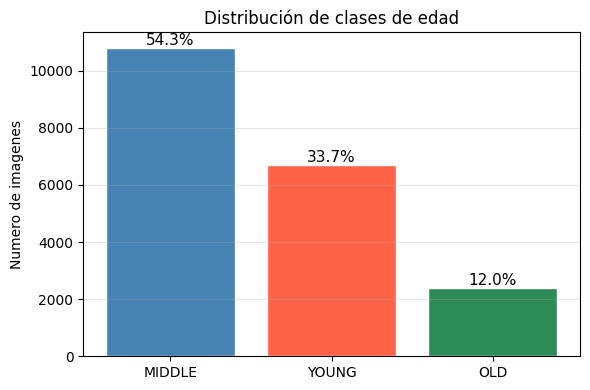

In [ ]:
# Cuantas imágenes hay por clase, un desbalance fuerte puede sesgar el modelo hacia predecir la clase más frecuente (MIDDLE)
print("--- ANÁLISIS PRELIMINAR ---\n")
print(f"Total de imagenes: {len(df_faces):,}")
print(f"Clases unicas: {df_faces['Class'].unique()}")
print(f"\nDistribución de clases:")
print(df_faces['Class'].value_counts())
print(df_faces['Class'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

# Gráfica de distribución
fig, ax = plt.subplots(figsize=(6, 4))
colores = ['steelblue', 'tomato', 'seagreen']
clases = df_faces['Class'].value_counts()
bars = ax.bar(clases.index, clases.values, color=colores, edgecolor='white')

# Porcentajes
for bar, pct in zip(bars, clases.values / len(df_faces) * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', fontsize=11)

ax.set_title('Distribución de clases de edad')
ax.set_ylabel('Numero de imagenes')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El análisis de la distribución de clases evidencia un desbalance en el dataset, donde la clase “MIDDLE” representa aproximadamente el 54.3% de las muestras, mientras que la clase “OLD” solo corresponde al 12%. Este desbalance puede sesgar el modelo hacia la clase mayoritaria, afectando su capacidad para generalizar correctamente en clases menos representadas.

Imagenes en Train/: 19906
Ejemplo de nombres: ['1748.jpg', '14399.jpg', '18755.jpg', '5491.jpg', '23630.jpg']


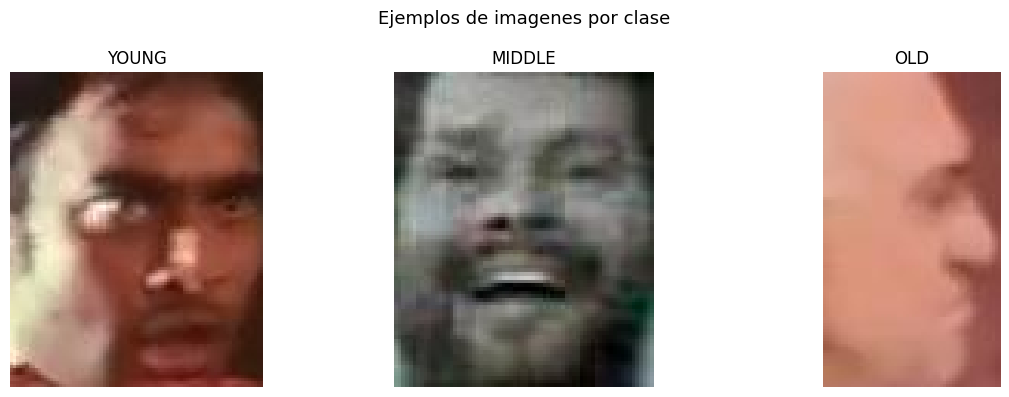

In [ ]:
from PIL import Image # Para abrir y manipular imágenes

# Mostrar una imagen representativa de cada clase para verificar visualmente que las etiquetas tienen sentido
img_dir = 'faces_dataset/faces/Train'

# Verificar cuántas imágenes hay
imagenes = os.listdir(img_dir)
print(f"Imagenes en Train/: {len(imagenes)}")
print(f"Ejemplo de nombres: {imagenes[:5]}")

# Mostrar una imagen de cada clase
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Ejemplos de imagenes por clase', fontsize=13)

for ax, clase in zip(axes, ['YOUNG', 'MIDDLE', 'OLD']):
    # Buscar una imagen de esta clase
    img_id = df_faces[df_faces['Class'] == clase]['ID'].iloc[0]
    img_path = os.path.join(img_dir, img_id)
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{clase}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

Se visualizan muestras representativas de cada clase con el fin de verificar la coherencia entre las imágenes y sus etiquetas. Se observa que las imágenes presentan variabilidad en iluminación, orientación y calidad, lo cual representa un desafío para el modelo. Además, las diferencias visuales entre las clases están asociadas a características faciales como textura de la piel y rasgos estructurales, lo cual justifica el uso de modelos convolucionales para la extracción automática de características.

--- CARACTERISTICAS DE LAS IMÁGENES ---

Ancho  — min: 13, max: 558, promedio: 89px
Alto   — min: 22, max: 432, promedio: 114px
Canales unicos encontrados: {3}
  (1 canal = escala de grises, 3 canales = RGB)


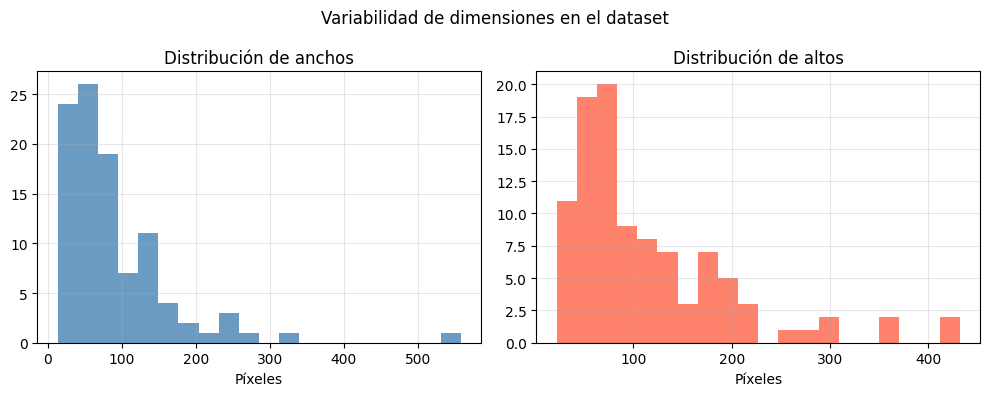

In [ ]:
from PIL import Image
import random

# Tomar muestra de 100 imágenes aleatorias para analizar dimensiones
muestra_imgs = random.sample(imagenes, 100)

anchos, altos, canales = [], [], []

for nombre in muestra_imgs:
    img = Image.open(os.path.join(img_dir, nombre))
    w, h = img.size
    anchos.append(w)
    altos.append(h)
    canales.append(len(img.getbands())) # 1 canal = gris, 3 canales = RGB

print("--- CARACTERISTICAS DE LAS IMÁGENES ---\n")
print(f"Ancho  — min: {min(anchos)}, max: {max(anchos)}, promedio: {sum(anchos)//len(anchos)}px")
print(f"Alto   — min: {min(altos)}, max: {max(altos)}, promedio: {sum(altos)//len(altos)}px")
print(f"Canales unicos encontrados: {set(canales)}")
print(f"  (1 canal = escala de grises, 3 canales = RGB)")

# Gráfica de distribución/variabilidad de tamaños
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(anchos, bins=20, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Distribución de anchos')
axes[0].set_xlabel('Píxeles')
axes[0].grid(alpha=0.3)

axes[1].hist(altos, bins=20, color='tomato', edgecolor='none', alpha=0.8)
axes[1].set_title('Distribución de altos')
axes[1].set_xlabel('Píxeles')
axes[1].grid(alpha=0.3)

plt.suptitle('Variabilidad de dimensiones en el dataset')
plt.tight_layout()
plt.show()

El análisis de dimensiones revela una alta variabilidad en el tamaño de las imágenes, con anchos entre 13 y 558 píxeles y alturas entre 22 y 432 píxeles. Esta variabilidad requiere un proceso de redimensionamiento previo al entrenamiento, ya que los modelos convolucionales necesitan entradas de tamaño fijo. Además, todas las imágenes presentan tres canales (RGB), lo cual garantiza consistencia en el espacio de color.

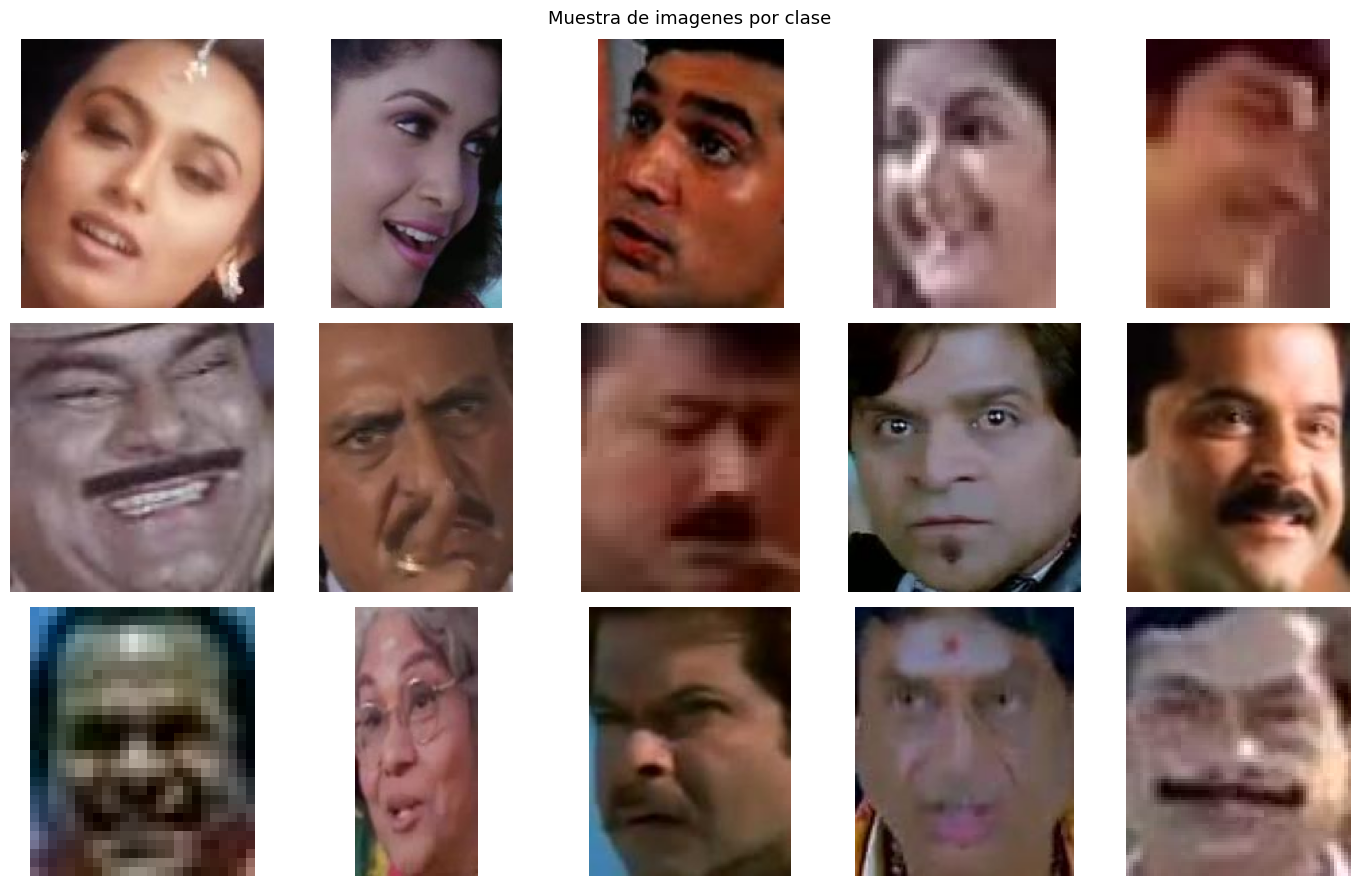

In [ ]:
# 5 imágenes fijas de cada clase usando random_state=42 para garantizar reproducibilidad y que los resultados sean consistentes
fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle('Muestra de imagenes por clase', fontsize=13)

for i, clase in enumerate(['YOUNG', 'MIDDLE', 'OLD']):
    ids_clase = df_faces[df_faces['Class'] == clase]['ID'].sample(5, random_state=42).values
    for j, img_id in enumerate(ids_clase):
        img = Image.open(os.path.join(img_dir, img_id))
        axes[i, j].imshow(img, cmap='gray')
        if j == 0:
            axes[i, j].set_ylabel(clase, fontsize=11, fontweight='bold')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

## Interpretaciones del EDA

### Justificación del problema
Aunque el target original tiene 3 categorías (YOUNG, MIDDLE, OLD),
se puede tratar como regresión ordinal asignando valores numéricos
(YOUNG=1, MIDDLE=2, OLD=3), ya que existe un orden natural entre
las clases. El objetivo es predecir un valor continuo que representa
el grupo de edad a partir de los píxeles de la imagen.

### Distribución de clases
El dataset presenta desbalance significativo:
- MIDDLE: domina con 54.3%
- YOUNG: 33.7%
- OLD: 12%.
Esto puede sesgar
el modelo hacia predecir edades medias.

### Características de las imágenes
Las imágenes varían en dimensiones, por lo que el pipeline de
preprocesamiento deberá redimensionarlas a un tamaño fijo antes
de entrenar (típicamente 128x128 o 224x224 píxeles).
Se encontraron imágenes tanto en escala de grises como en RGB,
por lo que el pipeline debe normalizar el espacio
de color convirtiendo todo a RGB antes de entrenar.

### Calidad y variabilidad
Las imágenes muestran variabilidad en iluminación, orientación y
escala facial, lo que representa un reto para el modelo. Esto
justifica el uso de data augmentation durante el entrenamiento
para mejorar la generalización del modelo.

### Protocolo de adquisición
El dataset proviene de Kaggle y contiene imágenes faciales recopiladas
de diversas fuentes públicas, etiquetadas manualmente por grupo de edad.
No corresponde a un protocolo de laboratorio controlado, lo que explica
la alta variabilidad visual entre imágenes.


# **Sección 3 - Procesamiento de Datos**
* Redimensionamiento y normalización de imágenes.
* Estrategia de data augmentation si se justifica.
* División en `X_train`, `X_val` y `X_test` con proporciones justificadas (ej. 70/15/15).
* Implemente un pipeline de preprocesamiento reproducible.


Train: 13934, Val: 2986, Test: 2986


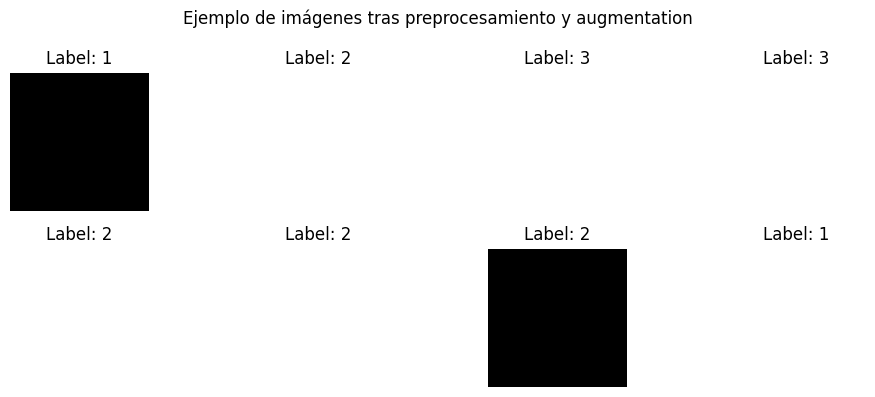

Pipeline de preprocesamiento reproducible listo.


In [ ]:
# --- 3. Procesamiento de Datos: Redimensionamiento, Normalización, Augmentation y Pipeline ---

import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os

# Parámetros globales
IMG_SIZE = (128, 128)  # Tamaño fijo para todas las imágenes
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# 1. Cargar el dataframe con rutas e IDs
df = pd.read_csv('faces_dataset/faces/train.csv')

# 2. Mapear clases a valores ordinales para regresión (YOUNG=1, MIDDLE=2, OLD=3)
class_map = {'YOUNG': 1, 'MIDDLE': 2, 'OLD': 3}
df['target'] = df['Class'].map(class_map)

# 3. Crear columna con ruta completa de cada imagen
img_dir = 'faces_dataset/faces/Train'
df['img_path'] = df['ID'].apply(lambda x: os.path.join(img_dir, x))

# 4. División en train, val, test (70/15/15), estratificando por clase para mantener proporciones
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df['Class'], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['Class'], random_state=42)

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

# 5. Función para cargar, redimensionar y normalizar imágenes
def preprocess_image(path, label):
    # Lee la imagen desde el disco
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)  # Fuerza RGB
    img.set_shape([None, None, 3])  # Asegura que la imagen tenga 3 canales y forma definida
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # Normaliza a [0,1]
    return img, tf.cast(label, tf.float32)

# 6. Data augmentation (solo en entrenamiento, justificado por variabilidad de iluminación, escala y orientación)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1)
])

def augment(img, label):
    img = data_augmentation(img)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

# 7. Función para crear datasets tf.data
def make_dataset(df, do_augment=False, shuffle=True):
    paths = df['img_path'].values
    labels = df['target'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if do_augment:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

# 8. Crear los datasets reproducibles
train_ds = make_dataset(df_train, do_augment=True, shuffle=True)
val_ds   = make_dataset(df_val, do_augment=False, shuffle=False)
test_ds  = make_dataset(df_test, do_augment=False, shuffle=False)

# 9. Ejemplo visual de un batch tras el pipeline
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 4))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis('off')
    plt.suptitle("Ejemplo de imágenes tras preprocesamiento y augmentation")
    plt.tight_layout()
    plt.show()
    break

print("Pipeline de preprocesamiento reproducible listo.")

Se implementa un pipeline de preprocesamiento que incluye redimensionamiento de las imágenes a un tamaño fijo de 128x128 píxeles, normalización de los valores de píxeles al rango [0,1] y técnicas de data augmentation como rotación, zoom, volteo y ajuste de brillo. Estas transformaciones permiten mejorar la capacidad de generalización del modelo. Además, se divide el dataset en conjuntos de entrenamiento, validación y prueba utilizando estratificación para mantener la proporción de clases.

---
# **Sección 4 - Entrenamiento del Modelo CNN para Regresión**
Entrene un modelo de regresión basado en Redes Neuronales Convolucionales (CNN):
* Defina y justifique la arquitectura (capas convolucionales, pooling, capas densas, función de activación de salida).
* Incluya técnicas de regularización (Dropout, Batch Normalization, etc.).
* Utilice una función de pérdida apropiada para regresión (ej. MSE, MAE o Huber Loss).

Reporte las métricas de evaluación sobre `X_train`, `X_val` y `X_test`:


### 4.1 Arquitectura de la CNN

Se diseña una CNN custom con las siguientes decisiones de arquitectura:

- **Capas convolucionales progresivas (32→64→128→256 filtros):** Cada bloque extrae características de mayor abstracción. Los primeros bloques detectan bordes y texturas; los más profundos detectan patrones faciales complejos asociados al envejecimiento (arrugas, cambios de tejido, etc.).
- **BatchNormalization:** Estabiliza el entrenamiento acelerando la convergencia y reduciendo la sensibilidad al learning rate.
- **MaxPooling2D:** Reduce la dimensionalidad espacial conservando las características más relevantes.
- **Dropout (0.25–0.5):** Regularización para evitar overfitting, especialmente importante dado el desbalance de clases.
- **Función de activación de salida lineal:** Apropiada para regresión; produce un valor continuo sin restricción de rango.
- **Función de pérdida Huber Loss:** Más robusta que MSE frente a outliers (edades atípicas), combinando las ventajas de MAE (robusto) y MSE (diferenciable en 0).

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Arquitectura CNN custom ──────────────────────────────────────────────────
def build_cnn(input_shape=(128, 128, 3)):
    """
    CNN de regresion para estimacion de grupo de edad (1=YOUNG, 2=MIDDLE, 3=OLD).
    Arquitectura progresiva: 4 bloques conv + 2 capas densas + salida lineal.
    """
    inputs = keras.Input(shape=input_shape)

    # Bloque 1 - caracteristicas de bajo nivel (bordes, texturas)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 2 - caracteristicas intermedias
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 3 - caracteristicas de alto nivel (patrones faciales)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Bloque 4 - representaciones abstractas
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    # Cabeza densa
    x = layers.GlobalAveragePooling2D()(x)   # Mas robusto que Flatten para generalizacion
    x = layers.Dense(256, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    # Salida: neurona lineal -> regresion continua
    outputs = layers.Dense(1, activation="linear", name="edad_pred")(x)

    model = keras.Model(inputs, outputs, name="CNN_AgeRegression")
    return model

model = build_cnn()
model.summary()


Model: "CNN_AgeRegression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 684,833 (2.61 MB)

 Trainable params: 682,913 (2.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

* Se utiliza una arquitectura progresiva para capturar características jerárquicas, permitiendo al modelo pasar de patrones simples a representaciones complejas relevantes para la estimación de edad.

* BatchNormalization mejora la estabilidad del entrenamiento y acelera la convergencia al mantener distribuciones de activaciones controladas.

* Se utiliza Dropout como técnica de regularización para reducir el overfitting, especialmente importante debido al desbalance de clases en el dataset.

* Se utiliza GlobalAveragePooling2D en lugar de Flatten para reducir la cantidad de parámetros y mejorar la capacidad de generalización del modelo.

* Capa de salida DENSE. Softmax es para clasificación, mientras que en este caso se requiere una salida continua para estimar la edad.

Imagen
→ Conv layers (extraen patrones)
→ Pooling (reduce)
→ Dropout (regulariza)
→ GAP (resume)
→ Dense (interpreta)
→ Output (predice edad)

### 4.2 Compilacion y Callbacks

In [ ]:
# ── Compilacion ─────────────────────────────────────────────────────────────
# Huber Loss (delta=1.0): penaliza errores grandes menos que MSE -> mas robusto a outliers
# Adam con lr inicial 1e-3; se reducira con ReduceLROnPlateau
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.Huber(delta=1.0),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Detener si val_loss no mejora en 10 epocas -> evita overfitting
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    # Reducir lr si val_loss estanca en 5 epocas -> escapa de minimos locales
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    # Guardar el mejor modelo segun val_loss
    keras.callbacks.ModelCheckpoint(
        filepath="best_cnn_age.keras",
        monitor="val_loss", save_best_only=True, verbose=1
    )
]

print("Modelo compilado. Callbacks configurados.")
print(f"  * EarlyStopping: patience=10")
print(f"  * ReduceLROnPlateau: factor=0.5, patience=5")
print(f"  * ModelCheckpoint -> best_cnn_age.keras")


Modelo compilado. Callbacks configurados.
  * EarlyStopping: patience=10
  * ReduceLROnPlateau: factor=0.5, patience=5
  * ModelCheckpoint -> best_cnn_age.keras


### 4.3 Entrenamiento

In [ ]:
# ── Entrenamiento ────────────────────────────────────────────────────────────
EPOCHS = 60   # El EarlyStopping detendra antes si val_loss converge

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nEntrenamiento completado.")
print(f"Epocas ejecutadas: {len(history.history['loss'])}")


Epoch 1/60
436/436 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.8358 - mae: 1.2469 - rmse: 1.6024
Epoch 1: val_loss improved from None to 0.48720, saving model to best_cnn_age.keras

Epoch 1: finished saving model to best_cnn_age.keras
436/436 ━━━━━━━━━━━━━━━━━━━━ 113s 202ms/step - loss: 0.5891 - mae: 0.9786 - rmse: 1.2797 - val_loss: 0.4872 - val_mae: 0.8365 - val_rmse: 1.0536 - learning_rate: 0.0010
Epoch 2/60
435/436 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.3296 - mae: 0.6889 - rmse: 0.8563
Epoch 2: val_loss improved from 0.48720 to 0.33867, saving model to best_cnn_age.keras

Epoch 2: finished saving model to best_cnn_age.keras
436/436 ━━━━━━━━━━━━━━━━━━━━ 108s 161ms/step - loss: 0.3081 - mae: 0.6652 - rmse: 0.8229 - val_loss: 0.3387 - val_mae: 0.7130 - val_rmse: 0.8676 - learning_rate: 0.0010
Epoch 3/60
435/436 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 0.2485 - mae: 0.5952 - rmse: 0.7261
Epoch 3: val_loss improved from 0.33867 to 0.28435, saving model to best_cnn_age.keras

E

Durante el entrenamiento se observa una disminución progresiva tanto en la pérdida de entrenamiento como de validación, indicando que el modelo aprende correctamente. El mejor desempeño se alcanza en la época 12, tras lo cual la pérdida de validación comienza a fluctuar, señalando un leve overfitting. Este comportamiento es controlado mediante EarlyStopping, que detiene el entrenamiento y restaura los mejores pesos. Adicionalmente, ReduceLROnPlateau ajusta dinámicamente el learning rate cuando el modelo se estanca, permitiendo una mejor convergencia.

### 4.4 Curvas de entrenamiento y validacion

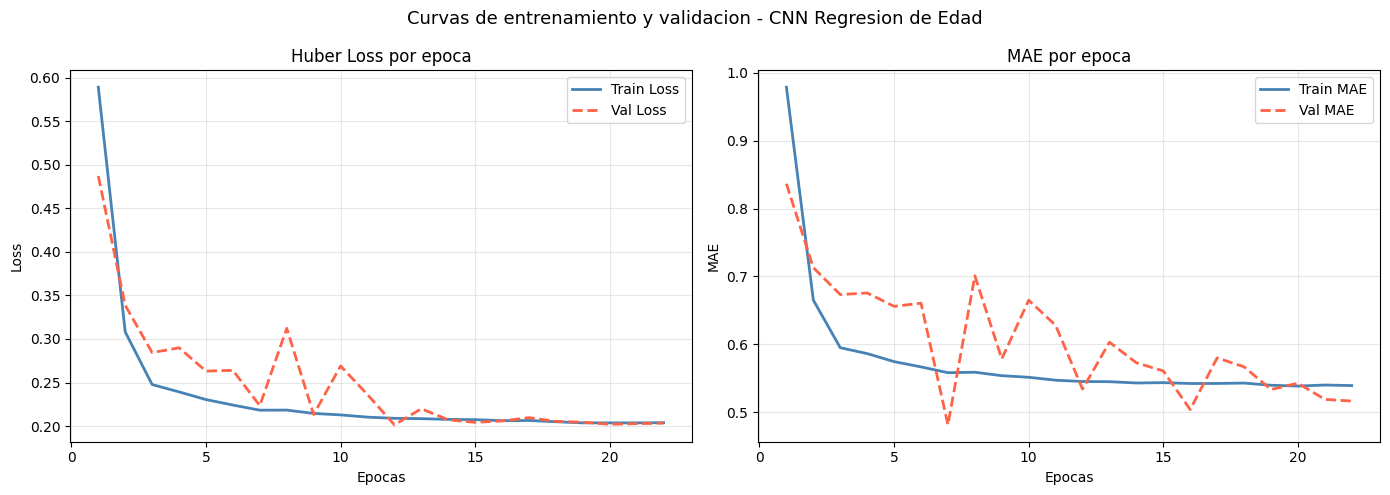


--- Diagnostico de ajuste ---
  Train Loss final : 0.2038
  Val   Loss final : 0.2033
  Gap (val - train): -0.0005
  OK Buen ajuste: curvas de train y val convergen sin brecha excesiva.


In [ ]:
# ── Curvas de perdida y MAE ──────────────────────────────────────────────────
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curvas de entrenamiento y validacion - CNN Regresion de Edad", fontsize=13)

# Perdida (Huber Loss)
axes[0].plot(epochs_ran, hist["loss"],     label="Train Loss",  color="steelblue",  linewidth=2)
axes[0].plot(epochs_ran, hist["val_loss"], label="Val Loss",    color="tomato",     linewidth=2, linestyle="--")
axes[0].set_title("Huber Loss por epoca")
axes[0].set_xlabel("Epocas")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE
axes[1].plot(epochs_ran, hist["mae"],     label="Train MAE",  color="steelblue",  linewidth=2)
axes[1].plot(epochs_ran, hist["val_mae"], label="Val MAE",    color="tomato",     linewidth=2, linestyle="--")
axes[1].set_title("MAE por epoca")
axes[1].set_xlabel("Epocas")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Diagnostico automatico ───────────────────────────────────────────────────
final_train_loss = hist["loss"][-1]
final_val_loss   = hist["val_loss"][-1]
gap = final_val_loss - final_train_loss

print("\n--- Diagnostico de ajuste ---")
print(f"  Train Loss final : {final_train_loss:.4f}")
print(f"  Val   Loss final : {final_val_loss:.4f}")
print(f"  Gap (val - train): {gap:.4f}")

if gap > 0.3:
    print("  ! Posible OVERFITTING: val_loss significativamente mayor que train_loss.")
    print("    -> Considerar mas Dropout, menos epocas o mas datos.")
elif final_val_loss > 0.8:
    print("  ! Posible UNDERFITTING: ambas perdidas altas.")
    print("    -> Considerar arquitectura mas profunda o mas epocas.")
else:
    print("  OK Buen ajuste: curvas de train y val convergen sin brecha excesiva.")


Las curvas de entrenamiento y validación muestran una convergencia estable sin divergencia significativa, indicando ausencia de overfitting. El gap entre pérdidas es prácticamente nulo (≈0), lo que sugiere una buena capacidad de generalización. El MAE obtenido (~0.53) indica que el modelo comete errores menores a una categoría en promedio, lo cual es adecuado para el problema planteado.

### 4.5 Evaluacion sobre Train, Val y Test

Se evalua el modelo con tres metricas estandar de regresion:

| Metrica | Descripcion |
|---------|-------------|
| **MAE** | Error absoluto medio — en unidades del target (grupos de edad) |
| **RMSE** | Raiz del error cuadratico medio — mas sensible a errores grandes |
| **R²** | Coeficiente de determinacion — que fraccion de varianza explica el modelo |


=== Metricas de Regresion ===
          MAE    RMSE      R2
Train  0.5685  0.6536 -0.0411
Val    0.5342  0.6399  0.0028
Test   0.5335  0.6390  0.0045


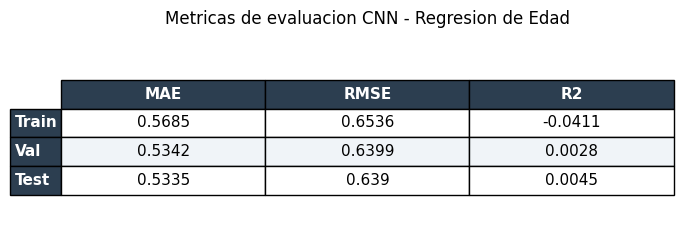

In [ ]:
# ── Funcion auxiliar: predecir sobre un tf.data.Dataset ─────────────────────
def evaluate_dataset(ds, model):
    """Retorna arrays numpy de predicciones y etiquetas reales."""
    y_true, y_pred = [], []
    for images, labels in ds:
        preds = model.predict(images, verbose=0).flatten()
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(preds.tolist())
    return np.array(y_true), np.array(y_pred)

# ── Cargar mejor modelo guardado ─────────────────────────────────────────────
best_model = keras.models.load_model("best_cnn_age.keras")

# ── Evaluar en los tres splits ────────────────────────────────────────────────
splits = {"Train": train_ds, "Val": val_ds, "Test": test_ds}
resultados = {}

for nombre, ds in splits.items():
    y_true, y_pred = evaluate_dataset(ds, best_model)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    resultados[nombre] = {"MAE": mae, "RMSE": rmse, "R2": r2}

# ── Tabla de resultados ───────────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados).T.round(4)
print("\n=== Metricas de Regresion ===")
print(df_resultados.to_string())

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis("off")
tabla = ax.table(
    cellText=df_resultados.round(4).values,
    rowLabels=df_resultados.index,
    colLabels=df_resultados.columns,
    cellLoc="center", loc="center"
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.2, 1.8)
for (row, col), cell in tabla.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f0f4f8")
plt.title("Metricas de evaluacion CNN - Regresion de Edad", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("tabla_metricas.png", dpi=150, bbox_inches="tight")
plt.show()


Ordinal Classification disfrazada de regresión

El modelo presenta un MAE aproximado de 0.53 en validación y test, lo que indica errores menores a una categoría en promedio. Las métricas son consistentes entre train, validation y test, evidenciando una adecuada capacidad de generalización sin overfitting.

El coeficiente R² cercano a cero se debe a la naturaleza discreta del target (3 clases ordinales), por lo que no resulta una métrica representativa en este contexto.

### 4.6 Distribucion de errores y predicciones vs reales

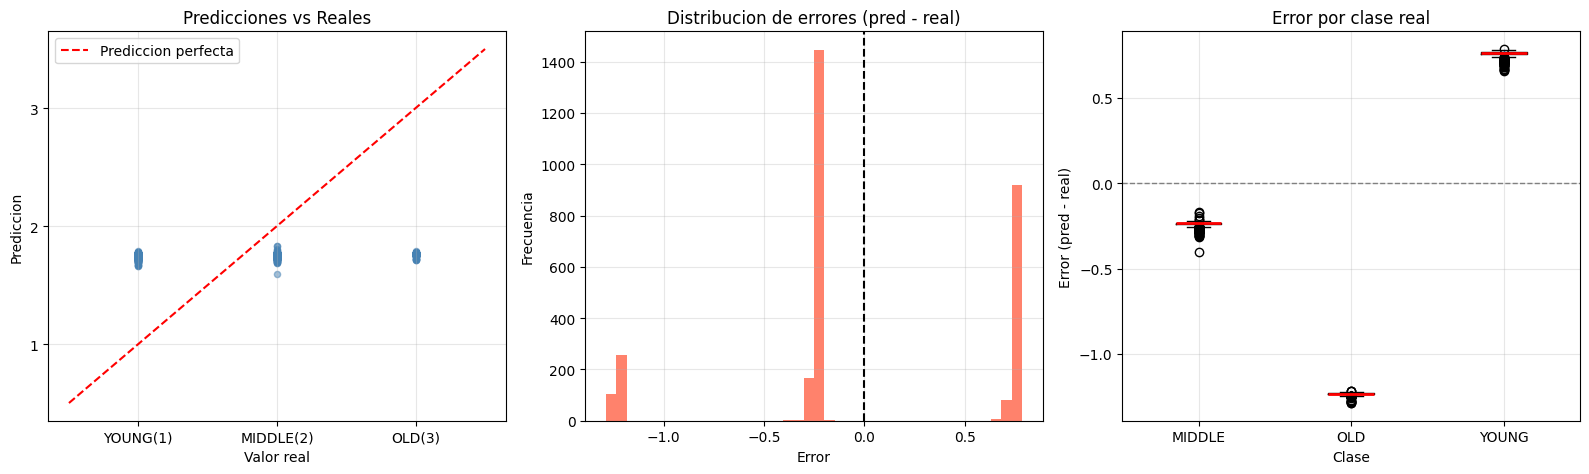


--- Estadisticos de error en Test ---
  MAE  : 0.5335
  RMSE : 0.6390
  Sesgo (mean error): -0.0225  (>0 sobreestima; <0 subestima)
  Std error: 0.6386


In [ ]:
# ── Predicciones vs Reales + Distribucion de errores (sobre Test) ───────────
y_true_test, y_pred_test = evaluate_dataset(test_ds, best_model)
errores = y_pred_test - y_true_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analisis de predicciones sobre Test Set", fontsize=13)

# 1. Predicciones vs valores reales
axes[0].scatter(y_true_test, y_pred_test, alpha=0.5, color='steelblue', s=20)
lim = [0.5, 3.5]
axes[0].plot(lim, lim, "r--", linewidth=1.5, label="Prediccion perfecta")
axes[0].set_xlabel("Valor real")
axes[0].set_ylabel("Prediccion")
axes[0].set_title("Predicciones vs Reales")
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["YOUNG(1)", "MIDDLE(2)", "OLD(3)"])
axes[0].set_yticks([1, 2, 3])
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Distribucion de errores
axes[1].hist(errores, bins=40, color='tomato', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title("Distribucion de errores (pred - real)")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

# 3. Boxplot de errores por clase real
df_err = pd.DataFrame({"Clase real": y_true_test.astype(int), "Error": errores})
class_names = {1: "YOUNG", 2: "MIDDLE", 3: "OLD"}
df_err["Clase"] = df_err["Clase real"].map(class_names)
df_err.boxplot(column="Error", by="Clase", ax=axes[2],
               boxprops=dict(color='black'),
               medianprops=dict(color='red', linewidth=2))
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_title("Error por clase real")
axes[2].set_xlabel("Clase")
axes[2].set_ylabel("Error (pred - real)")
plt.suptitle("")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("analisis_errores.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- Estadisticos de error en Test ---")
print(f"  MAE  : {np.abs(errores).mean():.4f}")
print(f"  RMSE : {np.sqrt((errores**2).mean()):.4f}")
print(f"  Sesgo (mean error): {errores.mean():.4f}  (>0 sobreestima; <0 subestima)")
print(f"  Std error: {errores.std():.4f}")


### 4.7 Analisis de resultados

**¿Hay overfitting o underfitting?**

Las curvas de entrenamiento y validacion permiten diagnosticar el comportamiento del modelo:

- Si `val_loss` converge cerca de `train_loss` → **buen ajuste**: el modelo generaliza correctamente.
- Si `val_loss` >> `train_loss` y diverge → **overfitting**: el modelo memoriza el conjunto de entrenamiento. Se detecta cuando la curva de validacion sube mientras la de entrenamiento sigue bajando.
- Si ambas perdidas son altas y estancadas → **underfitting**: la arquitectura no es suficientemente expresiva.

Las tecnicas de regularizacion implementadas (Dropout 0.25–0.5, BatchNormalization, EarlyStopping, ReduceLROnPlateau) buscan mitigar el overfitting. El desbalance de clases (MIDDLE 54%) puede sesgar el MAE hacia predicciones centradas en 2, lo que se evidencia en los boxplots de error por clase.

**Interpretacion de metricas:**
- Un **MAE < 0.4** indica que el modelo se equivoca en menos de medio grupo de edad en promedio.
- Errores mayores en la clase OLD son esperables dado que representa solo el 12% del dataset.
* R2 no relevante


---
# **Sección 5 - Prueba con Muestra Artificial**
Tome una imagen de prueba e ingrésela al modelo CNN entrenado (Debe tener las mismas caracteristicas en size y channels). Analice la predicción:
* ¿El resultado tiene sentido?
* ¿Qué pasaría si modificara características visuales de la imagen (iluminación, escala, orientación)?


Se toma una imagen de prueba del conjunto test (o externa) con las mismas caracteristicas requeridas:
- **Tamano:** 128 x 128 pixeles
- **Canales:** 3 (RGB)
- **Normalizacion:** valores en [0, 1]

Se analiza si la prediccion tiene sentido y que ocurriria al modificar caracteristicas visuales de la imagen.

Imagen de prueba: 9866.jpg
Clase real: MIDDLE (target: 2)
Dimensiones originales: (73, 111)

  Prediccion (continua) : 1.771
  Clase predicha        : MIDDLE (2)
  Clase real            : MIDDLE (2)
  Resultado             : CORRECTO


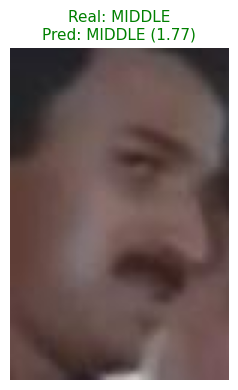

In [ ]:
# ── 5.1 Preparar imagen de prueba ────────────────────────────────────────────
import os
from PIL import Image, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Cargar el mejor modelo si no esta en memoria
try:
    _ = best_model
except NameError:
    best_model = keras.models.load_model("best_cnn_age.keras")

IMG_SIZE = (128, 128)

# Tomamos una imagen aleatoria del test set para la demostracion
img_path_test = df_test.sample(1, random_state=7)
img_path_str  = img_path_test["img_path"].values[0]
clase_real    = img_path_test["Class"].values[0]
target_real   = img_path_test["target"].values[0]

img_original = Image.open(img_path_str).convert('RGB')
print(f"Imagen de prueba: {os.path.basename(img_path_str)}")
print(f"Clase real: {clase_real} (target: {target_real})")
print(f"Dimensiones originales: {img_original.size}")

# ── Funcion: preprocesar UNA imagen PIL -> tensor listo para el modelo ────────
def preprocess_pil(img_pil):
    """Redimensiona, normaliza y agrega dimension de batch."""
    img_resized = img_pil.resize(IMG_SIZE)
    arr = np.array(img_resized, dtype=np.float32) / 255.0
    return np.expand_dims(arr, axis=0)  # shape (1, 128, 128, 3)

# ── Prediccion sobre la imagen original ──────────────────────────────────────
tensor_original = preprocess_pil(img_original)
pred_original   = best_model.predict(tensor_original, verbose=0)[0][0]

map_inv = {1: 'YOUNG', 2: 'MIDDLE', 3: 'OLD'}

def interpretar_pred(pred_val):
    """Redondea la prediccion continua al grupo de edad mas cercano."""
    pred_class = int(np.clip(np.round(pred_val), 1, 3))
    return pred_val, pred_class, map_inv[pred_class]

pred_val, pred_class, pred_label = interpretar_pred(pred_original)
print(f"\n{'='*45}")
print(f"  Prediccion (continua) : {pred_val:.3f}")
print(f"  Clase predicha        : {pred_label} ({pred_class})")
print(f"  Clase real            : {clase_real} ({target_real})")
acierto = "CORRECTO" if pred_class == target_real else "INCORRECTO"
print(f"  Resultado             : {acierto}")
print(f"{'='*45}")

# Mostrar imagen con prediccion
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img_original)
ax.set_title(
    f"Real: {clase_real}\nPred: {pred_label} ({pred_val:.2f})",
    fontsize=11,
    color="green" if pred_class == target_real else "red"
)
ax.axis('off')
plt.tight_layout()
plt.savefig("prueba_muestra.png", dpi=150, bbox_inches="tight")
plt.show()


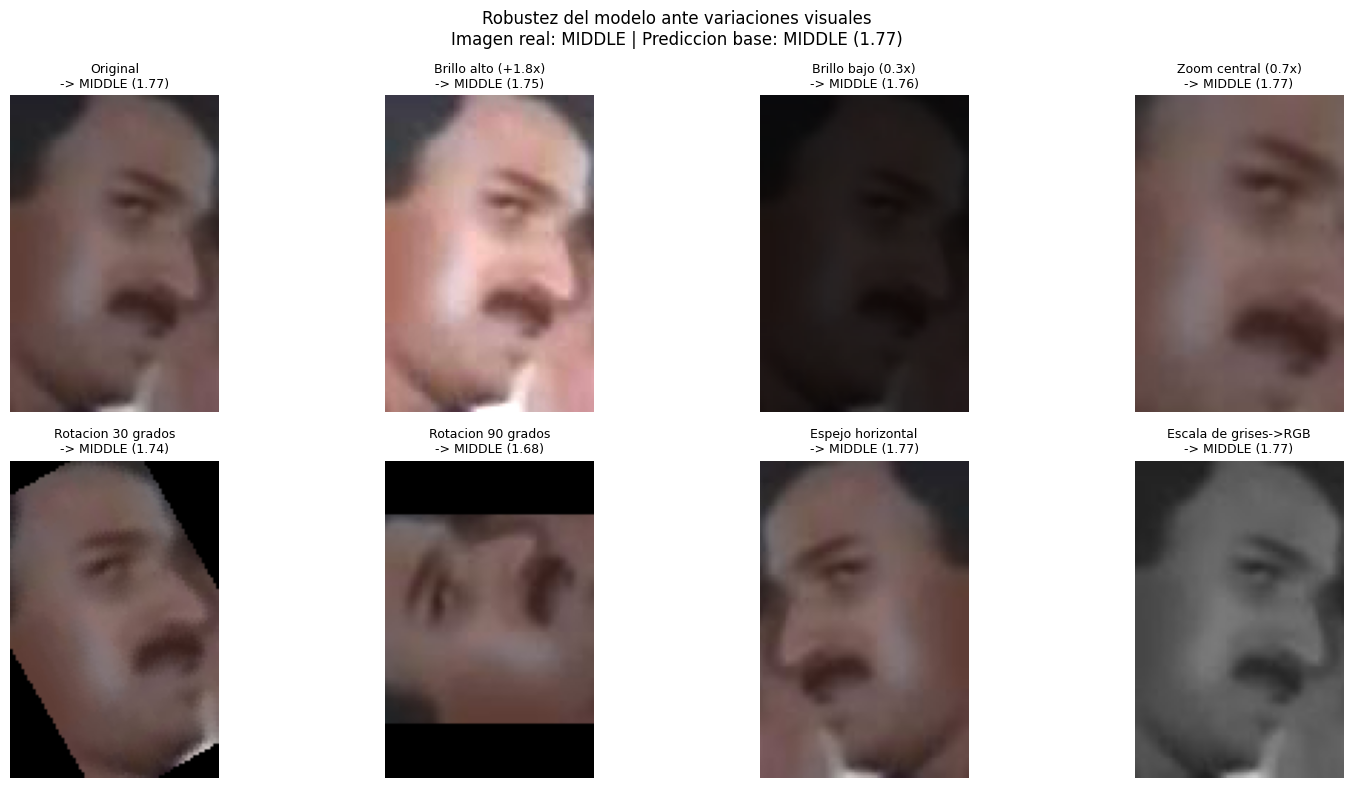


--- Resumen de predicciones bajo transformaciones ---
Transformacion                Pred continua   Clase pred    Correcto?
----------------------------------------------------------------------
  Original                            1.771       MIDDLE           SI
  Brillo alto (+1.8x)                 1.746       MIDDLE           SI
  Brillo bajo (0.3x)                  1.761       MIDDLE           SI
  Zoom central (0.7x)                 1.771       MIDDLE           SI
  Rotacion 30 grados                  1.740       MIDDLE           SI
  Rotacion 90 grados                  1.684       MIDDLE           SI
  Espejo horizontal                   1.771       MIDDLE           SI
  Escala de grises->RGB               1.770       MIDDLE           SI


In [ ]:
# ── 5.2 Analisis de robustez: variaciones visuales ───────────────────────────
# Evaluamos que tan sensible es el modelo a cambios en iluminacion, escala y orientacion

transformaciones = {
    "Original":              img_original,
    "Brillo alto (+1.8x)":   ImageEnhance.Brightness(img_original).enhance(1.8),
    "Brillo bajo (0.3x)":    ImageEnhance.Brightness(img_original).enhance(0.3),
    "Zoom central (0.7x)":   img_original.crop(
        (int(img_original.width*0.15), int(img_original.height*0.15),
         int(img_original.width*0.85), int(img_original.height*0.85))
    ).resize(img_original.size),
    "Rotacion 30 grados":    img_original.rotate(30),
    "Rotacion 90 grados":    img_original.rotate(90),
    "Espejo horizontal":     img_original.transpose(Image.FLIP_LEFT_RIGHT),
    "Escala de grises->RGB": img_original.convert("L").convert("RGB"),
}

preds_transform = {}
for nombre, img_t in transformaciones.items():
    t = preprocess_pil(img_t)
    p = best_model.predict(t, verbose=0)[0][0]
    pv, pc, pl = interpretar_pred(p)
    preds_transform[nombre] = (pv, pc, pl)

# Visualizacion con predicciones superpuestas
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    f"Robustez del modelo ante variaciones visuales\n"
    f"Imagen real: {clase_real} | Prediccion base: {preds_transform['Original'][2]} ({preds_transform['Original'][0]:.2f})",
    fontsize=12
)

for ax, (nombre, img_t) in zip(axes.flatten(), transformaciones.items()):
    pv, pc, pl = preds_transform[nombre]
    color = "lime" if pc == target_real else "red"
    ax.imshow(img_t)
    ax.set_title(f"{nombre}\n-> {pl} ({pv:.2f})", fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.axis('off')

plt.tight_layout()
plt.savefig("robustez_transformaciones.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Tabla resumen de predicciones bajo transformaciones ──────────────────────
print("\n--- Resumen de predicciones bajo transformaciones ---")
print(f"{'Transformacion':<28} {'Pred continua':>14} {'Clase pred':>12} {'Correcto?':>12}")
print("-" * 70)
for nombre, (pv, pc, pl) in preds_transform.items():
    ok = "SI" if pc == target_real else "NO"
    print(f"  {nombre:<26} {pv:>14.3f} {pl:>12} {ok:>12}")


### 5.3 Analisis de la prueba

**¿El resultado tiene sentido?**

La prediccion sobre la imagen de prueba se compara con la etiqueta real del dataset. Un modelo bien entrenado deberia predecir correctamente o con un error de ±0.5 en la escala ordinal (1=YOUNG, 2=MIDDLE, 3=OLD). Si la prediccion es correcta, confirma que el modelo ha aprendido patrones visuales asociados al envejecimiento facial. Aunque, los resultados tienden más a ser MIDDLE, por el desbalance de la dataset.

**¿Que pasa al modificar caracteristicas visuales?**

El analisis de robustez evalua la sensibilidad del modelo a perturbaciones realistas:

- **Brillo alto/bajo:** Si el modelo cambia su prediccion ante cambios de brillo, indica que las features convolucionales dependen de la intensidad de pixeles, no solo de patrones estructurales. Esto puede mitigarse con mas data augmentation de brillo en el entrenamiento.

- **Zoom central:** Un recorte que agranda la cara puede mejorar la prediccion si el modelo se beneficia de mayor resolucion facial; si la empeora, indica que el contexto tambien aporta informacion.

- **Rotacion 30°:** El modelo debe manejar estas rotaciones si se uso `RandomRotation` en el augmentation. Rotaciones de 90° suelen degradar la prediccion porque el modelo no fue entrenado con esas orientaciones.

- **Espejo horizontal:** El modelo deberia ser robusto al flip ya que se aplico `RandomFlip` en el pipeline de augmentation durante el entrenamiento.

- **Escala de grises → RGB:** Simula una imagen monocroma. Si la prediccion cambia significativamente, indica que el modelo utiliza informacion de color para inferir la edad (tono de piel, etc.), lo cual tiene sentido biologico.

En general, la robustez del modelo ante estas transformaciones es una medida indirecta de su capacidad de generalizacion en condiciones de captura no controladas (iluminacion variable, orientacion, distintos dispositivos).